In [39]:
%matplotlib inline

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=32"
os.environ["OMP_NUM_THREADS"] = "32"
os.environ["MKL_NUM_THREADS"] = "32"
os.environ["NUMEXPR_NUM_THREADS"] = "32"
os.environ["OPENBLAS_NUM_THREADS"] = "32"
os.environ["VECLIB_MAXIMUM_THREADS"] = "32"
os.environ["NUMBA_NUM_THREADS"] = "32"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"


import jax 
import numpyro

numpyro.set_host_device_count(30)
jax.config.update("jax_enable_x64", True)

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import scipy.stats as st
from scipy.optimize import minimize

from scipy.special import erf, gamma, gammainc
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid, cumulative_trapezoid

#import emcee
#import corner

In [40]:
df = pd.read_csv(f's82_multiband_fitted.csv', index_col=0)

def split_log_sigma(d, key):
    try:
        log_sigma = np.array(d[key].strip('[]').split(), dtype=float)
        d[f'{key}_1'], d[f'{key}_2'], d[f'{key}_3'] = log_sigma[0], log_sigma[1], log_sigma[2]
    except:
        d[f'{key}_1'], d[f'{key}_2'], d[f'{key}_3'] = np.nan, np.nan, np.nan
    return d

df = df.apply(partial(split_log_sigma, key='log_sigma'), axis=1)
df = df.apply(partial(split_log_sigma, key='log_sigma_err'), axis=1)
df = df.apply(partial(split_log_sigma, key='log_jitter'), axis=1)
df = df.apply(partial(split_log_sigma, key='magerrs_mean'), axis=1)

df = df.dropna(subset=['log_jitter'])
df = df.dropna(subset=['magerrs_mean_1'])

print(len(df))

for band in [1,2,3]:
    df = df[(10**df[f'log_sigma_{band}']) > np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2)]

print(len(df))

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        # If the SDSS name is not found in the fits data, return the original dictionary
        return d
    i = i[0]
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['z_sys_lines'] = fits_data['ZSYS_LINES'][i]
    d['z_sys_lines_err'] = fits_data['ZSYS_LINES_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
    d['apparent_mag_i_err'] = 2.5/np.log(10) * (1/fits_data_2['PSFFLUX_IVAR'][i,3]**2)/fits_data_2['PSFFLUX'][i,3]
    return d

df = df.apply(populate_sdss_fields, axis=1)

df = df.dropna(subset=['apparent_mag_i', 'M_i'])

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['g']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

df = df.apply(calc_lam_RF, axis=1)

df = df[df['log_mbh'] > 1]
df = df[df['log_tau_rest'] > 0]

print(len(df))

df.head()

df.keys()

1755
823


/tmp/ipykernel_1070177/105986651.py:44: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
/tmp/ipykernel_1070177/105986651.py:44: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
/tmp/ipykernel_1070177/105986651.py:44: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
/tmp/ipykernel_1070177/105986651.py:44: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
/tmp/ipykernel_1070177/105986651.py:44: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
/tmp/ipykernel_1070177/105986651.py:44: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) 

803


Index(['object_id', 'sdss_name', 'z', 'log_lbol', 'log_lbol_err',
       'log_tau_rest', 'log_tau_rest_err', 'log_sigma', 'log_sigma_err',
       'log_jitter', 'magerrs_mean', 'log_sigma_1', 'log_sigma_2',
       'log_sigma_3', 'log_sigma_err_1', 'log_sigma_err_2', 'log_sigma_err_3',
       'log_jitter_1', 'log_jitter_2', 'log_jitter_3', 'magerrs_mean_1',
       'magerrs_mean_2', 'magerrs_mean_3', 'log_mbh', 'log_mbh_err',
       'log_ledd_ratio', 'log_ledd_ratio_err', 'z_sys_lines',
       'z_sys_lines_err', 'ebv', 'M_i', 'apparent_mag_i', 'apparent_mag_i_err',
       'log_lambda_RF'],
      dtype='object')

In [41]:
import numpyro
import jax
from numpyro.infer import MCMC, NUTS
import numpyro.distributions as dist

# Define the model for sampling
def model(apparent_mag_i, apparent_mag_i_err, log_sigma_1, log_tau_rest, log_lambda_RF, log_sigma_err_1, log_tau_rest_err, magerrs_mean_1, z):
    # print("apparent_mag_i", apparent_mag_i)
    # print("apparent_mag_i_err", apparent_mag_i_err)
    # print("log_sigma_1", log_sigma_1)
    # print("log_tau_rest", log_tau_rest)
    
    alpha = numpyro.sample("alpha", dist.Uniform(-10, 10))
    beta = numpyro.sample("beta", dist.Uniform(-10, 10))
    gamma = numpyro.sample("gamma", dist.Uniform(-20, 20))
    M0 = numpyro.sample("M0", dist.Uniform(-100, -10))
    log_f = numpyro.sample("log_f", dist.Uniform(-5, 0))
    
    mu_pred = apparent_mag_i - M0 - alpha * log_sigma_1 - beta * log_tau_rest - gamma * log_lambda_RF
    mu_pred_err = jax.numpy.sqrt(apparent_mag_i_err**2 + (alpha * log_sigma_err_1)**2 +
                                 (beta * log_tau_rest_err)**2 + magerrs_mean_1**2 + jax.numpy.exp(2 * log_f))
    
    mu_model = cosmo.distmod(z).value
    numpyro.sample("obs", dist.Normal(mu_model, mu_pred_err), obs=mu_pred)

# Run MCMC
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=2000, num_chains=2)
mcmc.run(jax.random.PRNGKey(0), 
df['apparent_mag_i'].to_numpy(), 
df['apparent_mag_i_err'].to_numpy(), 
df['log_sigma_1'].to_numpy(), 
df['log_tau_rest'].to_numpy(), 
df['log_lambda_RF'].to_numpy(), 
df['log_sigma_err_1'].to_numpy(), 
df['log_tau_rest_err'].to_numpy(), 
df['magerrs_mean_1'].to_numpy(), 
df['z'].to_numpy())

# Get the posterior samples
samples = mcmc.get_samples()

/tmp/ipykernel_1070177/2930976887.py:28: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=2000, num_chains=2)
sample: 100%|██████████| 3000/3000 [00:04<00:00, 644.61it/s, 63 steps of size 2.79e-02. acc. prob=0.93] 


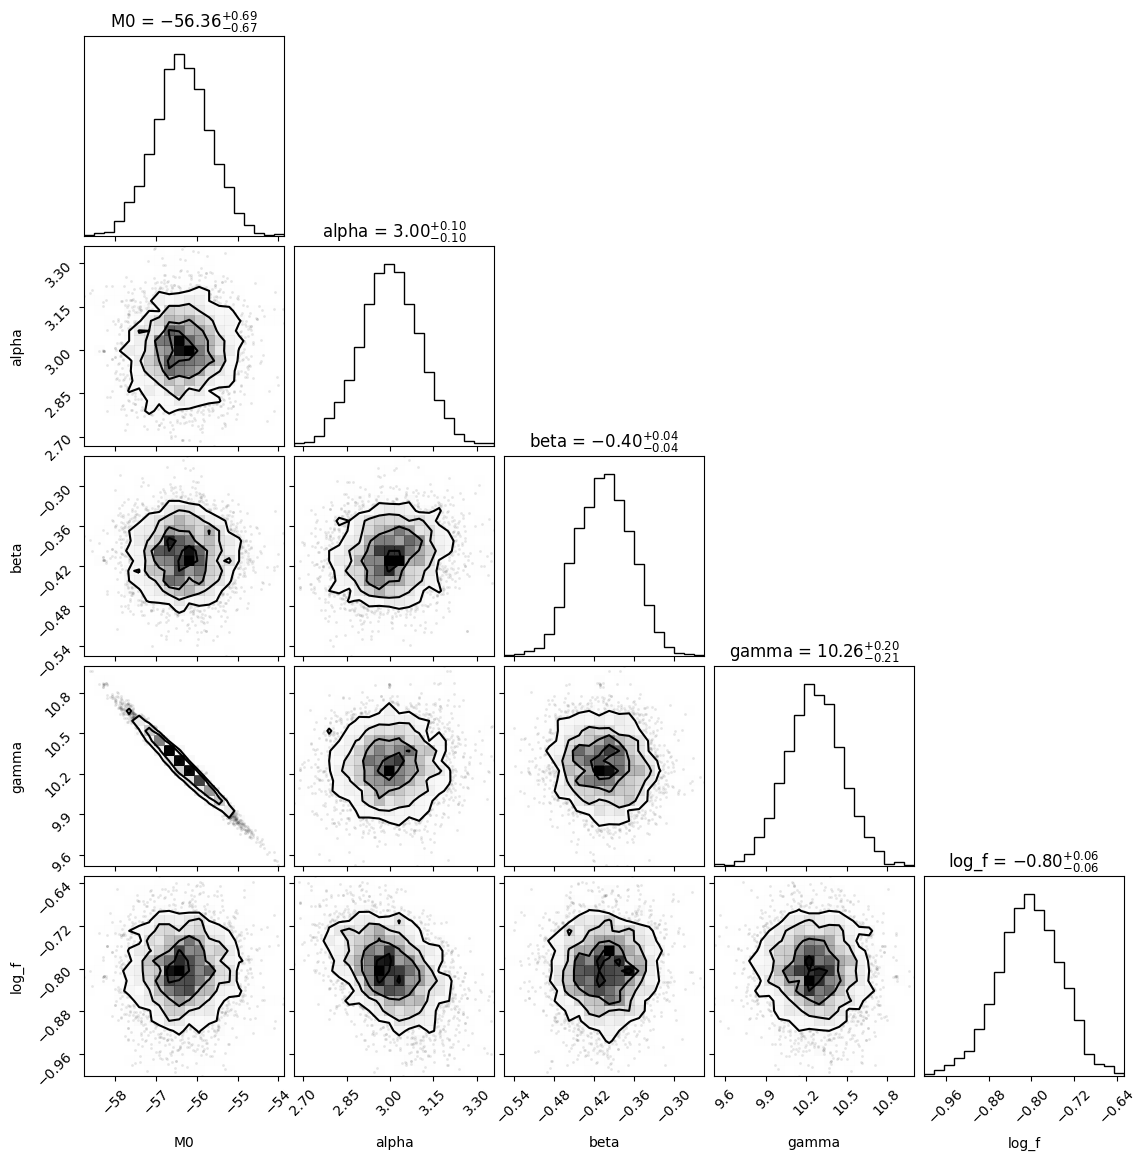

In [42]:
import corner

# Extract the posterior samples
posterior_samples = {
    "M0": samples["M0"],
    "alpha": samples["alpha"],
    "beta": samples["beta"],
    "gamma": samples["gamma"],
    "log_f": samples["log_f"]
}

# Convert the samples to a 2D array for corner
data = np.vstack([posterior_samples[key] for key in posterior_samples.keys()]).T

# Create the corner plot
fig = corner.corner(data, labels=list(posterior_samples.keys()), show_titles=True)

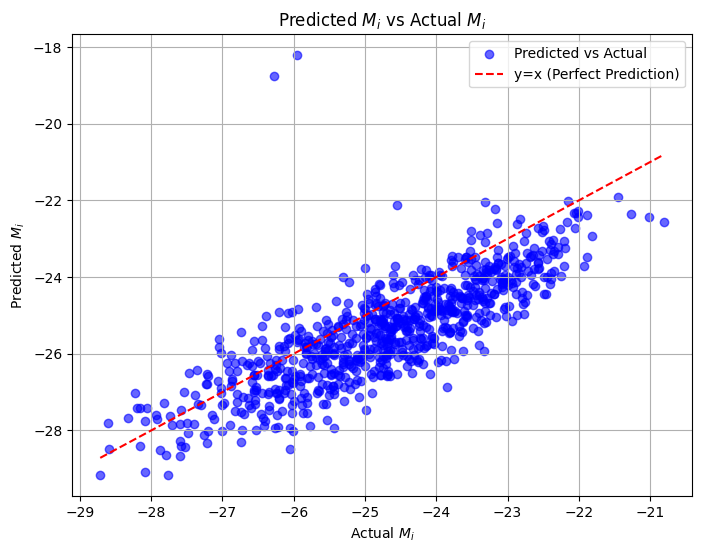

In [48]:
import matplotlib.pyplot as plt

# Assuming `predicted_M_i` contains the predicted M_i values
mu_pred_median = np.median(posterior_samples["M0"]) + np.median(posterior_samples["alpha"]) * df["log_sigma_1"].to_numpy() + \
                  np.median(posterior_samples["beta"]) * df["log_tau_rest"].to_numpy() + \
                  np.median(posterior_samples["gamma"]) * df["log_lambda_RF"].to_numpy()
# Extract actual M_i values from the dataframe
actual_M_i = df['M_i']

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(actual_M_i, mu_pred_median, c='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([actual_M_i.min(), actual_M_i.max()], [actual_M_i.min(), actual_M_i.max()], 'r--', label='y=x (Perfect Prediction)')
plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon

/tmp/ipykernel_1070177/3507461940.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.88590,0.864470,0.0991,1.4960,0.0381,0.005,1.000,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.30640,0.812220,0.0971,1.4960,-0.0252,0.003,1.000,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.50000,0.000358,0.0399,0.7134,0.0545,0.019,1.000,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.12200,0.000193,0.0931,0.7134,0.0622,0.028,1.000,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.83900,0.988740,0.0567,0.6110,0.0650,0.009,1.000,0.006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,rutledge,106,1.61505,0.00545,1.61499,0.00500,1.61399,0.00500,25.90650,0.331927,...,1.7256,8,2.92493,0.938980,0.2230,0.0106,-0.0203,0.005,1.000,0.002
1697,geta,106,1.69706,0.04006,1.69702,0.04000,1.70000,0.04000,26.03330,0.379521,...,1.8973,12,9.15387,0.689730,0.3209,0.0748,0.2680,0.005,0.633,0.000
1698,stone,106,1.80119,0.02014,1.80111,0.02000,1.80000,0.02000,26.23350,0.280685,...,1.1631,11,11.69320,0.387140,0.2370,0.0358,-0.0968,0.004,0.641,0.000
1699,wilson,106,1.91165,0.00263,1.91160,0.00100,1.91401,0.00100,26.17030,0.357624,...,1.4902,9,5.54378,0.784570,0.3168,0.0044,-0.3835,0.013,0.604,0.000


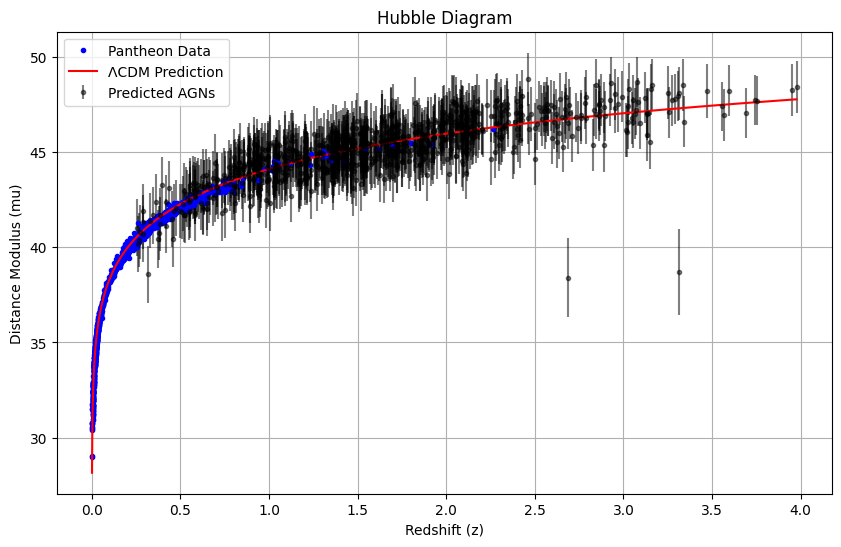

In [77]:
# Extract the predicted mu parameters from the posterior samples
mu_pred_median = df['apparent_mag_i'] - np.median(posterior_samples["M0"]) - np.median(posterior_samples["alpha"]) * df["log_sigma_1"].to_numpy() - \
                  np.median(posterior_samples["beta"]) * df["log_tau_rest"].to_numpy() - \
                  np.median(posterior_samples["gamma"]) * df["log_lambda_RF"].to_numpy()

mu_pred_16th = df['apparent_mag_i'] - np.percentile(posterior_samples["M0"], 16) - np.percentile(posterior_samples["alpha"], 16) * df["log_sigma_1"].to_numpy() - \
                np.percentile(posterior_samples["beta"], 16) * df["log_tau_rest"].to_numpy() - \
                np.percentile(posterior_samples["gamma"], 16) * df["log_lambda_RF"].to_numpy()

mu_pred_84th = df['apparent_mag_i'] - np.percentile(posterior_samples["M0"], 84) - np.percentile(posterior_samples["alpha"], 84) * df["log_sigma_1"].to_numpy() -\
                np.percentile(posterior_samples["beta"], 84) * df["log_tau_rest"].to_numpy() - \
                np.percentile(posterior_samples["gamma"], 84) * df["log_lambda_RF"].to_numpy()

mu_pred_std = np.abs(0.5 * (mu_pred_84th - mu_pred_16th))

# Plot the Hubble diagram
plt.figure(figsize=(10, 6))
#plt.errorbar(df["z"], mu, yerr=dmu, fmt='o', label="Observed AGNs", alpha=0.5, color="blue")
plt.errorbar(df["z"], mu_pred_median, yerr=mu_pred_std, fmt='.', label="Predicted AGNs", alpha=0.5, color="k")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")



z_grid = np.geomspace(0.001, df['z'].max(), 1000)
plt.plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()